Connecting to NOAA climate server for ML training data...
Training Random Forest machine learning model on ocean time-series...
Model Evaluation Results:
R² Score: 0.888 (1.0 is a perfect prediction)
Root Mean Squared Error: 0.576 °C


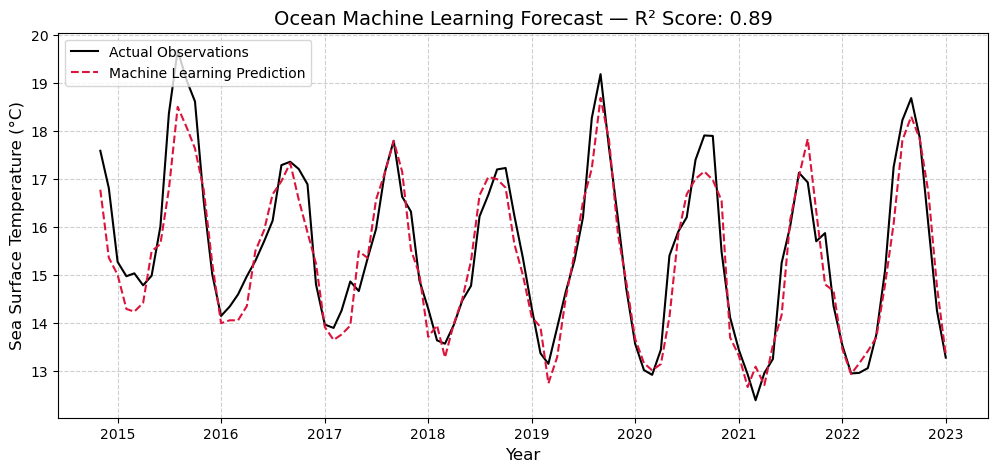

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Connect to NOAA's monthly OISST dataset via OPeNDAP
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2/sst.mnmean.nc"
print("Connecting to NOAA climate server for ML training data...")
ds = xr.open_dataset(url).sortby('lat')

# 2. Extract a specific ocean location (e.g., off the coast of California: 35°N, 235°E / 125°W)
point_data = ds.sst.sel(lat=35.0, lon=235.0, method='nearest').load()

# Convert to a clean Pandas DataFrame
df = point_data.to_dataframe().reset_index()
df = df.dropna(subset=['sst'])

# 3. Feature Engineering: Create lag variables
# To predict temperature this month, the model can look at the temperature 1 month and 2 months ago, plus seasonal month data.
df['month'] = df['time'].dt.month
df['sst_lag1'] = df['sst'].shift(1)  # SST 1 month ago
df['sst_lag2'] = df['sst'].shift(2)  # SST 2 months ago
df = df.dropna() # Remove rows with missing lag values

# 4. Define Features (X) and Target (y)
X = df[['month', 'sst_lag1', 'sst_lag2']]
y = df['sst']  # Target: Current SST

# Split into Training Data (80%) and Testing Data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Train the Machine Learning Model (Random Forest Regressor)
print("Training Random Forest machine learning model on ocean time-series...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Predict and Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Evaluation Results:")
print(f"R² Score: {r2:.3f} (1.0 is a perfect prediction)")
print(f"Root Mean Squared Error: {rmse:.3f} °C")

# 7. Plot Machine Learning Predictions vs Real Observations
plt.figure(figsize=(12, 5))
plt.plot(df['time'].iloc[-len(y_test):], y_test, label='Actual Observations', color='black', linewidth=1.5)
plt.plot(df['time'].iloc[-len(y_test):], y_pred, label='Machine Learning Prediction', color='crimson', linestyle='--', linewidth=1.5)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Sea Surface Temperature (°C)", fontsize=12)
plt.title(f"Ocean Machine Learning Forecast — R² Score: {r2:.2f}", fontsize=14)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Save output figure
plt.savefig("../figures/machine_learning_ocean_forecast.png", dpi=300, bbox_inches='tight')
plt.show()